In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [4]:
from boulder_statistics.analysis.quick_calculate import FittingFunction
fit = FittingFunction(dp, LAD_min = 2)

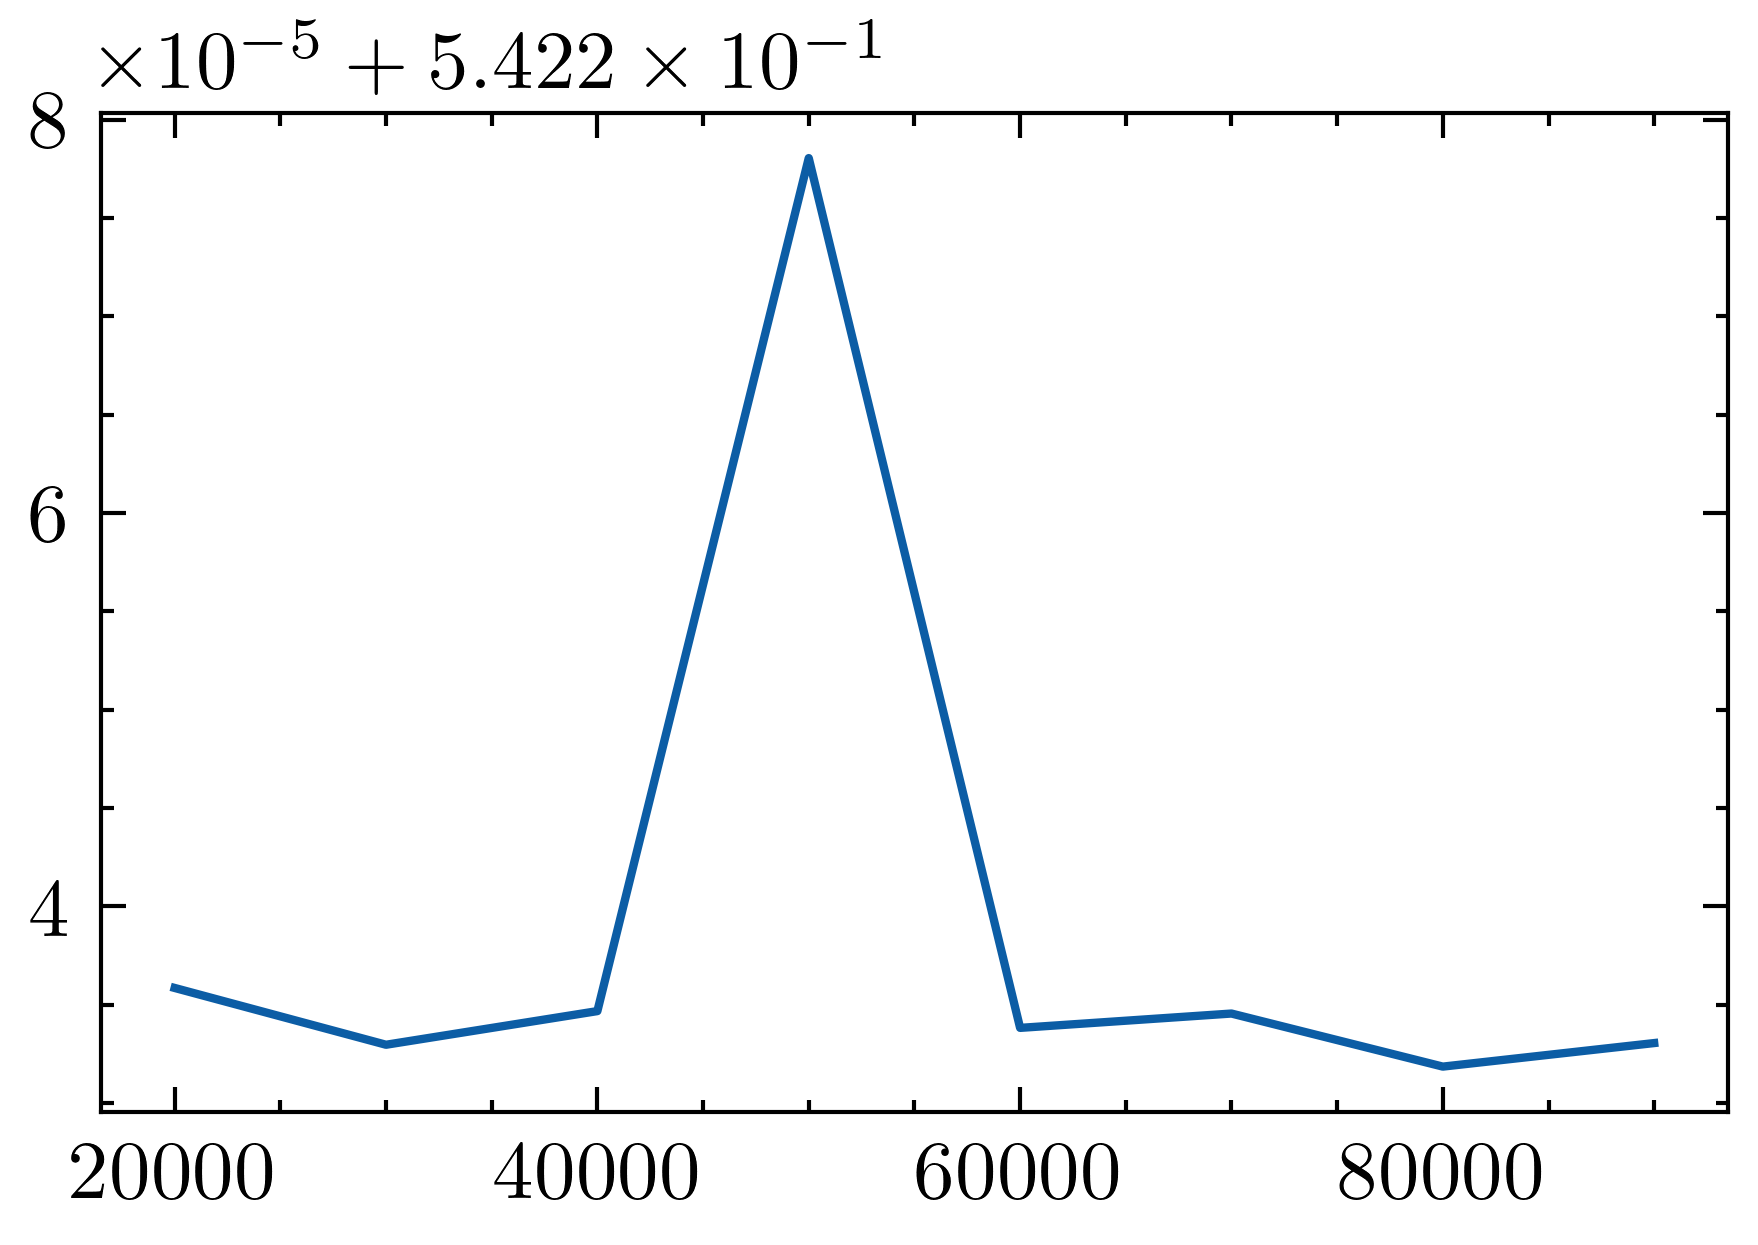

In [8]:
from scipy.integrate import trapezoid

results = []
samples = np.arange(20_000, 100_000, 10_000)

for sample in samples:
    alphas = np.geomspace(1, 1e6, sample)

    probs = fit.F(alphas, 0.47, g = 1, q = 1.3)
    finite_alphas = alphas[probs > 0]
    finite_probs = probs[probs > 0]

    res = np.abs(trapezoid(finite_alphas, finite_probs))

    results.append(res)


plt.plot(samples, results)